# Aachen Day-Night v1.1 Localization Pipeline (HLoc)
Bu notebook, guncel dataset yapisina gore Aachen Day-Night uzerinde SuperPoint + NetVLAD + LightGlue ile lokalizasyonu calistirir.
Ayrica localization sonucundan visual localization benchmark ile uyumlu translation/rotation error metriklerini hesaplamak icin bir degerlendirme hucresi icerir.

In [1]:
# Package kontrolu ve gerekirse kurulum
import importlib.util
import subprocess
import sys

required_packages = [
    ('numpy', 'numpy'),
    ('cv2', 'opencv-python'),
    ('h5py', 'h5py'),
    ('tqdm', 'tqdm'),
    ('scipy', 'scipy'),
    ('matplotlib', 'matplotlib'),
    ('plotly', 'plotly'),
    ('kornia', 'kornia'),
    ('gdown', 'gdown'),
    ('torch', 'torch'),
    ('torchvision', 'torchvision'),
    ('pycolmap', 'pycolmap>=3.13.0'),
    ('pandas', 'pandas'),
    ('lightglue', 'git+https://github.com/cvg/LightGlue'),
]

missing_pip_specs = [
    pip_spec for module_name, pip_spec in required_packages
    if importlib.util.find_spec(module_name) is None
]

print('Missing packages:', missing_pip_specs)
if missing_pip_specs:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', *missing_pip_specs])
    print('Installed packages:', missing_pip_specs)
else:
    print('Tum gerekli paketler zaten kurulu.')

Missing packages: []
Tum gerekli paketler zaten kurulu.


In [2]:
# Proje kokunu bul ve import path'e ekle
import sys
from pathlib import Path

cwd = Path.cwd().resolve()
candidates = [cwd, cwd.parent, cwd / 'VisualLocalization', cwd.parent / 'VisualLocalization']
project_root = next((p.resolve() for p in candidates if (p / 'hloc').exists()), None)
if project_root is None:
    raise FileNotFoundError('Could not find project root containing hloc/.')

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

print('Project root:', project_root)

Project root: G:\bitirme-proje\VisualLocalization


In [3]:
# Temel importlar
import copy
import gc
import h5py
from pathlib import Path
from pprint import pformat

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from hloc import (
    extract_features,
    localize_sfm,
    logger,
    match_features,
    pairs_from_covisibility,
    pairs_from_retrieval,
    triangulation,
    visualization as hloc_visualization,
 )
from hloc.utils.read_write_model import qvec2rotmat

print('Imports ready.')
print('Torch version:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('CUDA device:', torch.cuda.get_device_name(0))

Imports ready.
Torch version: 2.11.0+cu128
CUDA available: True
CUDA device: NVIDIA GeForce RTX 3050 Ti Laptop GPU


In [4]:
# Dataset ve output yollari (day + night intrinsics destegi)
dataset_candidates = [
    project_root.parent / 'datasets' / 'aachen-day-night',
    project_root / 'datasets' / 'aachen-day-night',
    Path('../datasets/aachen-day-night').resolve(),
    Path('datasets/aachen-day-night').resolve(),
]
dataset = next((p for p in dataset_candidates if p.exists()), None)
if dataset is None:
    raise FileNotFoundError('Aachen Day-Night dataset not found in expected locations.')

images = dataset / 'images_upright'
db_dir = images / 'db'
query_dir = images / 'query'
sift_sfm = dataset / '3D-models' / 'aachen_v_1_1'
queries_dir = dataset / 'queries'

day_queries_file = queries_dir / 'day_time_queries_with_intrinsics.txt'
night_queries_file = queries_dir / 'night_time_queries_with_intrinsics.txt'
query_files = [p for p in [day_queries_file, night_queries_file] if p.exists()]

required = [dataset, images, db_dir, query_dir, sift_sfm, queries_dir]
for p in required:
    if not p.exists():
        raise FileNotFoundError(f'Missing required path: {p}')

if not query_files:
    raise FileNotFoundError(
        'Neither day nor night intrinsics query file was found under dataset/queries/.'
    )

outputs = (project_root.parent / 'outputs' / 'aachen_v1_1_test').resolve()
outputs.mkdir(parents=True, exist_ok=True)

# Day + night query satirlari bu dosyada birlestirilecek ve localize_sfm'e verilecek.
queries_file = outputs / 'queries-day-night-with-intrinsics.txt'

reference_sfm = outputs / 'sfm_superpoint+lightglue'
sfm_pairs = outputs / 'pairs-db-covis20.txt'
loc_pairs = outputs / 'pairs-query-netvlad50.txt'
results = outputs / 'Aachen-v1.1_hloc_superpoint+lightglue_netvlad50.txt'

# Genel parametreler
num_covis = 20
num_loc = 50

# Mod secimi (CUDA'dan bagimsiz):
# - 'lightweight_own_sfm': daha kisa surede kendi SfM modelini olusturur
# - 'official_sift_reference': resmi SIFT modelini referans alir
reference_mode = 'lightweight_own_sfm'

# Hafif kendi SfM profili (kisa sure + daha dusuk kaynak)
sfm_fast_num_covis = 10
sfm_fast_max_keypoints = 3072
sfm_fast_resize_max = 960
sfm_fast_skip_geometric_verification = True

has_cuda = torch.cuda.is_available()

print('Dataset:', dataset)
print('Images root:', images)
print('DB dir:', db_dir)
print('Query dir:', query_dir)
print('Query intrinsics sources:', [p.name for p in query_files])
print('Merged queries file:', queries_file)
print('SIFT model:', sift_sfm)
print('Outputs:', outputs)
print('CUDA detected:', has_cuda)
print('Reference mode:', reference_mode)

Dataset: G:\bitirme-proje\datasets\aachen-day-night
Images root: G:\bitirme-proje\datasets\aachen-day-night\images_upright
DB dir: G:\bitirme-proje\datasets\aachen-day-night\images_upright\db
Query dir: G:\bitirme-proje\datasets\aachen-day-night\images_upright\query
Query intrinsics sources: ['day_time_queries_with_intrinsics.txt', 'night_time_queries_with_intrinsics.txt']
Merged queries file: G:\bitirme-proje\outputs\aachen_v1_1_test\queries-day-night-with-intrinsics.txt
SIFT model: G:\bitirme-proje\datasets\aachen-day-night\3D-models\aachen_v_1_1
Outputs: G:\bitirme-proje\outputs\aachen_v1_1_test
CUDA detected: True
Reference mode: lightweight_own_sfm


In [ ]:
# Query intrinsics dosyalarini oku, birlestir ve image listelerini olustur
query_intrinsics = []
source_counts = {}

for q_file in query_files:
    valid_count = 0
    for line in q_file.read_text(encoding='utf-8').splitlines():
        line = line.strip()
        if not line or line.startswith('#'):
            continue
        parts = line.split()
        if len(parts) < 8:
            continue
        query_intrinsics.append(parts)
        valid_count += 1
    source_counts[q_file.name] = valid_count

if not query_intrinsics:
    raise RuntimeError(f'No valid query lines found in: {query_files}')

# Query ismine gore tekillestir (ilk goruleni koru), sonra deterministik sirala.
unique_by_name = {}
for parts in query_intrinsics:
    qname = parts[0]
    if qname not in unique_by_name:
        unique_by_name[qname] = parts

query_intrinsics = [unique_by_name[name] for name in sorted(unique_by_name.keys())]

# localize_sfm icin day+night birlesik intrinsics dosyasi yaz
queries_file.write_text(
    '\n'.join(' '.join(parts) for parts in query_intrinsics) + '\n',
    encoding='utf-8',
)

db_images_all = sorted([p.relative_to(images).as_posix() for p in db_dir.rglob('*') if p.is_file()])
query_from_txt_all = sorted({x[0] for x in query_intrinsics})
query_images_all = [q for q in query_from_txt_all if (images / q).exists()]

missing_query_images = sorted(set(query_from_txt_all) - set(query_images_all))
if missing_query_images:
    print(f'Warning: {len(missing_query_images)} query image path(s) from txt not found under images_upright.')
    print('Example missing:', missing_query_images[:5])

db_images = db_images_all
query_images = query_images_all
extract_image_list = sorted(set(db_images + query_images))

# Configs: SuperPoint + NetVLAD + LightGlue
retrieval_conf = copy.deepcopy(extract_features.confs['netvlad'])
feature_conf = copy.deepcopy(extract_features.confs['superpoint_aachen'])
matcher_conf = copy.deepcopy(match_features.confs['superpoint+lightglue'])

logger.info('Feature extractor confs:\n%s', pformat(extract_features.confs))
logger.info('Matcher confs:\n%s', pformat(match_features.confs))

features = extract_features.main(
    feature_conf,
    images,
    outputs,
    image_list=extract_image_list,
    overwrite=False,
)

print('Intrinsics rows per source:', source_counts)
print('Merged intrinsics rows:', len(query_intrinsics))
print('Merged intrinsics file:', queries_file)
print('Local features:', features)
print('DB images:', len(db_images), '/', len(db_images_all))
print('Query images:', len(query_images), '/', len(query_from_txt_all))
print('Images to extract:', len(extract_image_list))

[2026/05/04 21:08:38 hloc INFO] Feature extractor confs:
{'aliked-n16': {'model': {'model_name': 'aliked-n16', 'name': 'aliked'},
                'output': 'feats-aliked-n16',
                'preprocessing': {'grayscale': False, 'resize_max': 1024}},
 'd2net-ss': {'model': {'multiscale': False, 'name': 'd2net'},
              'output': 'feats-d2net-ss',
              'preprocessing': {'grayscale': False, 'resize_max': 1600}},
 'dir': {'model': {'name': 'dir'},
         'output': 'global-feats-dir',
         'preprocessing': {'resize_max': 1024}},
 'disk': {'model': {'max_keypoints': 5000, 'name': 'disk'},
          'output': 'feats-disk',
          'preprocessing': {'grayscale': False, 'resize_max': 1600}},
 'megaloc': {'model': {'name': 'megaloc'},
             'output': 'global-feats-megaloc',
             'preprocessing': {'resize_max': 1024}},
 'netvlad': {'model': {'name': 'netvlad'},
             'output': 'global-feats-netvlad',
             'preprocessing': {'resize_max': 1024

Intrinsics rows per source: {'day_time_queries_with_intrinsics.txt': 824, 'night_time_queries_with_intrinsics.txt': 191}
Merged intrinsics rows: 1015
Merged intrinsics file: G:\bitirme-proje\outputs\aachen_v1_1_test\queries-day-night-with-intrinsics.txt
Local features: G:\bitirme-proje\outputs\aachen_v1_1_test\feats-superpoint-n4096-r1024.h5
DB images: 4479 / 4479
Query images: 1015 / 1015
Images to extract: 5494


: 

In [12]:
# Alternatif A: Kisa surede kendi referans SfM modelini olustur (Batch Triangulation)
if reference_mode != 'lightweight_own_sfm':
    print("Skipping this cell (reference_mode != 'lightweight_own_sfm').")
else:
    # Daha hizli calismasi icin lokal feature yogunlugunu dusur.
    feature_conf['model']['max_keypoints'] = sfm_fast_max_keypoints
    feature_conf['preprocessing']['resize_max'] = sfm_fast_resize_max

    # Bu ayarlar degistigi icin local features'i bu profile gore tekrar cikar.
    features = extract_features.main(
        feature_conf,
        images,
        outputs,
        image_list=extract_image_list,
        overwrite=False,
    )

    # Kendi model olusturma adimi: daha az covis pair
    pairs_from_covisibility.main(
        sift_sfm,
        sfm_pairs,
        num_matched=sfm_fast_num_covis,
    )

    # *** Matching adimi - bu önemli! ***
    sfm_matches = match_features.main(
        matcher_conf,
        sfm_pairs,
        feature_conf['output'],
        outputs,
    )
    
    print(f"Matching tamamlandı: {sfm_matches}")

    # --- Batch Triangulation ---
    import subprocess
    
    # Pair dosyasını oku
    with open(sfm_pairs, 'r') as f:
        all_pairs = [l.strip() for l in f if l.strip()]
    
    print(f"Toplam {len(all_pairs)} pair")
    
    # Batch ayarları
    batch_size = 50
    overlap = 5
    step = batch_size - overlap
    
    reference_sfm = outputs / 'sfm_custom_model'
    reference_sfm.mkdir(parents=True, exist_ok=True)
    
    # Unique image'ları bul
    all_images_set = set()
    for p in all_pairs:
        parts = p.split()
        if len(parts) == 2:
            img1, img2 = parts
            all_images_set.add(img1)
            all_images_set.add(img2)
    
    all_images = sorted(all_images_set)
    print(f"Toplam {len(all_images)} unique image")
    
    # Batch'ler
    batch_count = 0
    for batch_idx in range(0, len(all_images), step):
        batch_images = set(all_images[batch_idx:batch_idx + batch_size])
        batch_pairs = [p for p in all_pairs if any(img in batch_images for img in p.split())]
        
        if not batch_pairs:
            continue
        
        batch_count += 1
        print(f"\nBatch {batch_count}: {len(batch_pairs)} pair, {len(batch_images)} image")
        
        # Temp pairs dosyası
        temp_pairs = Path(outputs) / f"batch_pairs_{batch_idx}.txt"
        with open(temp_pairs, 'w') as f:
            f.write('\n'.join(batch_pairs))
        
        # Triangulation
        try:
            features_path = Path(features)
            sfm_matches_path = Path(sfm_matches)

            triangulation.main(
                reference_sfm,
                sift_sfm,
                images,
                str(temp_pairs),
                features_path,
                sfm_matches_path,
                skip_geometric_verification=True,
            )
            print(f"  ✓ Batch {batch_count} tamamlandı")
        except Exception as e:
            print(f"  ✗ Hata: {e}")
            continue
        finally:
            gc.collect()
    
    reference_for_loc = reference_sfm
    quick_mode = False
    print(f'\n✓ Custom SfM model oluşturuldu: {reference_sfm}')
    print('Fast profile -> covis:', sfm_fast_num_covis, ', max_kp:', sfm_fast_max_keypoints, ', resize_max:', sfm_fast_resize_max)

[2026/05/04 22:38:07 hloc INFO] Extracting local features with configuration:
{'model': {'max_keypoints': 3072, 'name': 'superpoint', 'nms_radius': 3},
 'output': 'feats-superpoint-n4096-r1024',
 'preprocessing': {'grayscale': True, 'resize_max': 960}}
[2026/05/04 22:38:11 hloc INFO] Skipping the extraction.
[2026/05/04 22:38:11 hloc INFO] Reading the COLMAP model...
[2026/05/04 22:38:49 hloc INFO] Extracting image pairs from covisibility info...
100%|██████████| 6697/6697 [01:07<00:00, 98.58it/s] 
[2026/05/04 22:39:57 hloc INFO] Found 66911 pairs.
[2026/05/04 22:39:59 hloc INFO] Matching local features with configuration:
{'model': {'features': 'superpoint', 'name': 'lightglue'},
 'output': 'matches-superpoint-lightglue'}
[2026/05/04 22:40:04 hloc INFO] Skipping the matching.


Matching tamamlandı: G:\bitirme-proje\outputs\aachen_v1_1_test\feats-superpoint-n4096-r1024_matches-superpoint-lightglue_pairs-db-covis20.h5
Toplam 66911 pair
Toplam 6697 unique image

Batch 1: 817 pair, 50 image
  ✗ Hata: 'str' object has no attribute 'exists'

Batch 2: 1052 pair, 50 image
  ✗ Hata: 'str' object has no attribute 'exists'

Batch 3: 814 pair, 50 image
  ✗ Hata: 'str' object has no attribute 'exists'

Batch 4: 777 pair, 50 image
  ✗ Hata: 'str' object has no attribute 'exists'

Batch 5: 689 pair, 50 image
  ✗ Hata: 'str' object has no attribute 'exists'

Batch 6: 711 pair, 50 image
  ✗ Hata: 'str' object has no attribute 'exists'

Batch 7: 790 pair, 50 image
  ✗ Hata: 'str' object has no attribute 'exists'

Batch 8: 854 pair, 50 image
  ✗ Hata: 'str' object has no attribute 'exists'

Batch 9: 880 pair, 50 image
  ✗ Hata: 'str' object has no attribute 'exists'

Batch 10: 853 pair, 50 image
  ✗ Hata: 'str' object has no attribute 'exists'

Batch 11: 960 pair, 50 image
  ✗ 

In [ ]:
# Alternatif B: Quick/reference modu (resmi SIFT modelini referans al)
if reference_mode != 'official_sift_reference':
    print("Skipping this cell (reference_mode != 'official_sift_reference').")
else:
    reference_for_loc = sift_sfm
    quick_mode = True
    print('Quick/reference mode ON: using official SIFT model as reference.')
    print('Reference SfM:', reference_for_loc)

Quick/reference mode ON: using official SIFT model as reference.
Reference SfM: G:\bitirme-proje\datasets\aachen-day-night\3D-models\aachen_v_1_1


In [9]:
# Retrieval + query localization matching
from hloc.utils.read_write_model import read_images_binary

if not (reference_for_loc / 'images.bin').exists():
    raise FileNotFoundError(f"images.bin not found in reference model: {reference_for_loc}")

# Referans modeldeki tum DB image isimleri
ref_images = read_images_binary(reference_for_loc / 'images.bin')
db_images_model = sorted({im.name for im in ref_images.values()})

# Diskte gercekten olanlar
db_images_model_existing = [n for n in db_images_model if (images / n).exists()]
missing_on_disk = sorted(set(db_images_model) - set(db_images_model_existing))

print('Reference DB images in model:', len(db_images_model))
print('Reference DB images found on disk:', len(db_images_model_existing))
print('Missing DB images on disk:', len(missing_on_disk))
if missing_on_disk:
    print('Example missing:', missing_on_disk[:5])

# Descriptor/feature extraction listesi: referans DB + query
retrieval_image_list = sorted(set(db_images_model_existing + query_images))

# Global descriptors (retrieval icin gerekli)
global_descriptors = extract_features.main(
    retrieval_conf,
    images,
    outputs,
    image_list=retrieval_image_list,
    overwrite=False,
)

# Local features (match/localize icin gerekli)
features = extract_features.main(
    feature_conf,
    images,
    outputs,
    image_list=retrieval_image_list,
    overwrite=False,
)

pairs_from_retrieval.main(
    descriptors=global_descriptors,
    output=loc_pairs,
    num_matched=num_loc,
    query_list=query_images,
    db_model=reference_for_loc,
)

loc_matches = match_features.main(
    matcher_conf,
    loc_pairs,
    feature_conf['output'],
    outputs,
)

print('Global descriptors:', global_descriptors)
print('Local features:', features)
print('Localization pairs:', loc_pairs)
print('Localization matches:', loc_matches)

FileNotFoundError: images.bin not found in reference model: G:\bitirme-proje\outputs\aachen_v1_1_test\sfm_custom_model

In [ ]:
# Sanity check: retrieval pair'lerdeki DB isimleri referans modelde var mı?
ref_names = {im.name for im in read_images_binary(reference_for_loc / 'images.bin').values()}
bad = []
for line in loc_pairs.read_text(encoding='utf-8').splitlines():
    s = line.strip()
    if not s:
        continue
    q, db = s.split()
    if db not in ref_names:
        bad.append((q, db))

print('Pairs not in reference model:', len(bad))
print('Example:', bad[:5])

Pairs not in reference model: 0
Example: []


In [ ]:
# Query'leri intrinsics ile birlikte localize et (6DoF)
queries_for_loc = queries_file

# localize_sfm intrinsics txt dosyasindaki model/parametreleri dogrudan kullanir.
localize_sfm.main(
    reference_for_loc,
    queries_for_loc,
    loc_pairs,
    features,
    loc_matches,
    results,
    covisibility_clustering=False,
 )

print('Results file:', results)
print('Queries used:', queries_for_loc)

[2026/04/24 03:38:20 hloc.utils.parsers INFO] Imported 1015 images from queries-day-night-with-intrinsics.txt
[2026/04/24 03:38:20 hloc INFO] Reading the 3D model...
[2026/04/24 03:38:31 hloc INFO] Starting localization...
100%|██████████| 1015/1015 [43:24<00:00,  2.57s/it] 
[2026/04/24 04:21:55 hloc INFO] Localized 1015 / 1015 images.
[2026/04/24 04:21:55 hloc INFO] Writing poses to G:\bitirme-proje\outputs\aachen_v1_1_test\Aachen-v1.1_hloc_superpoint+lightglue_netvlad50.txt...
[2026/04/24 04:21:55 hloc INFO] Writing logs to G:\bitirme-proje\outputs\aachen_v1_1_test\Aachen-v1.1_hloc_superpoint+lightglue_netvlad50.txt_logs.pkl...
[2026/04/24 04:22:26 hloc INFO] Done!


Results file: G:\bitirme-proje\outputs\aachen_v1_1_test\Aachen-v1.1_hloc_superpoint+lightglue_netvlad50.txt
Queries used: G:\bitirme-proje\outputs\aachen_v1_1_test\queries-day-night-with-intrinsics.txt


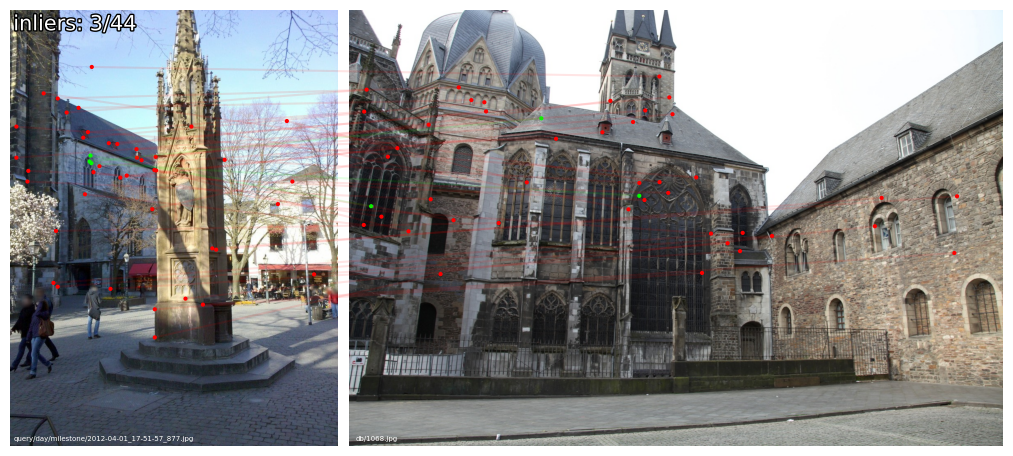

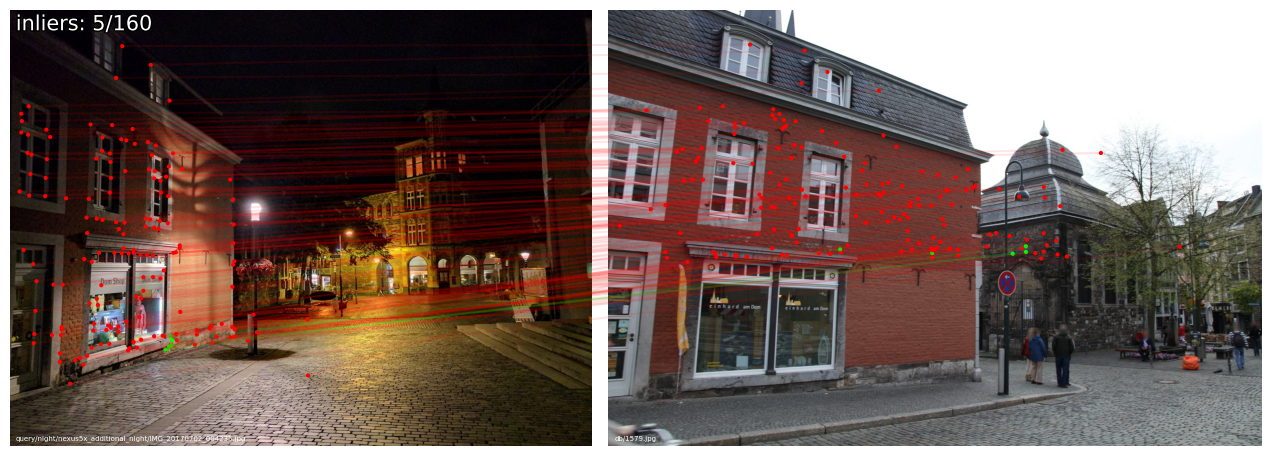

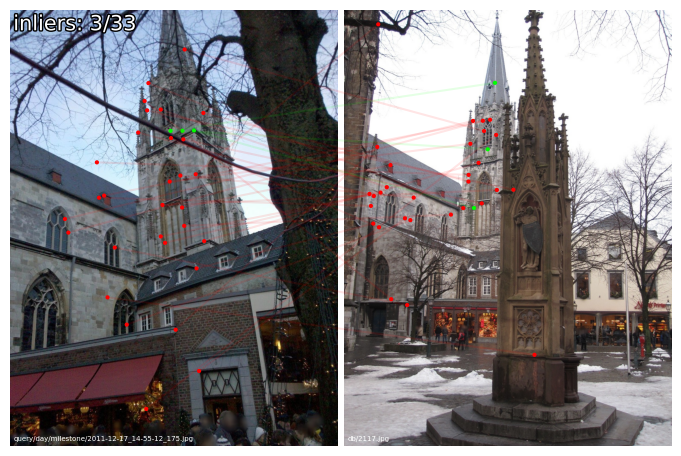

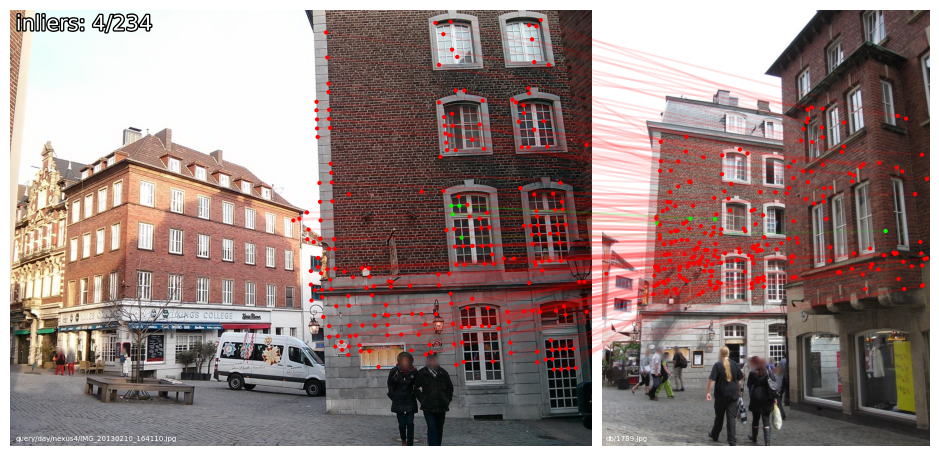

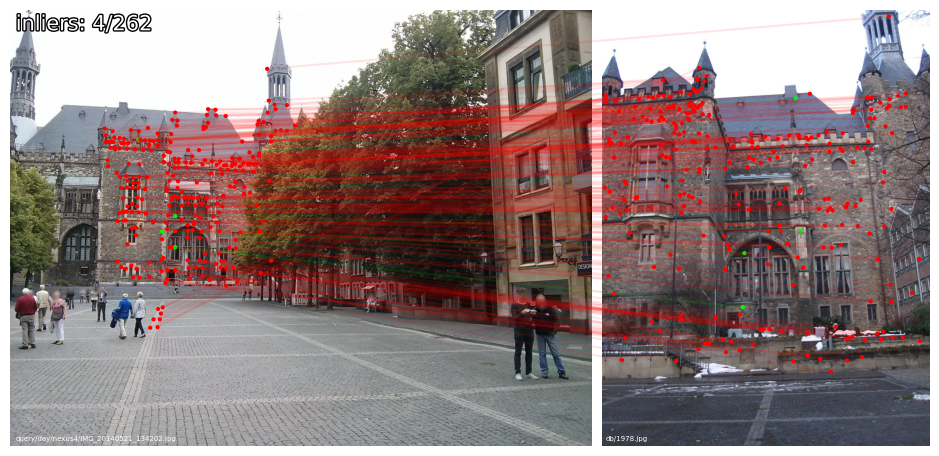

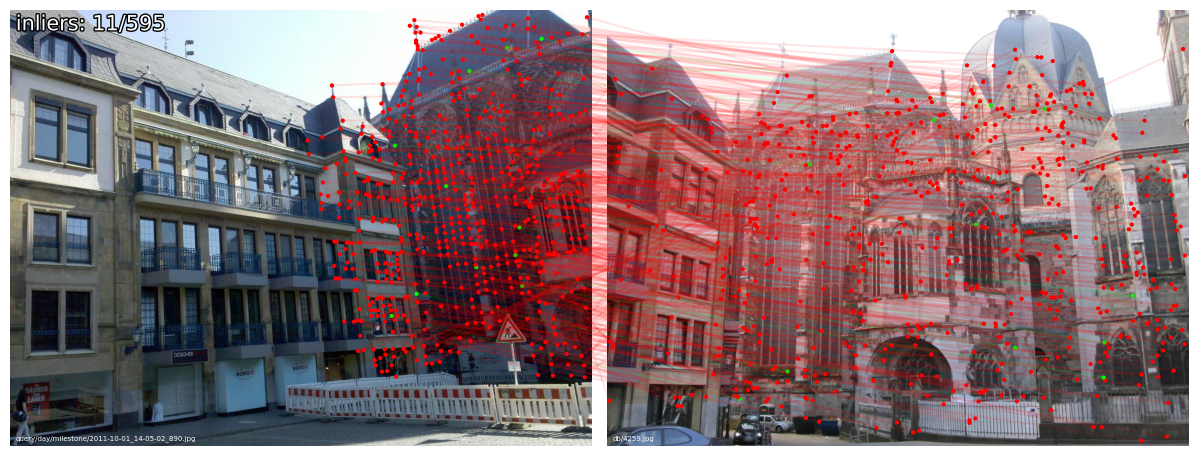

Visualized 6 query localization result(s).


In [ ]:
# Query localization gorsellestirme
num_vis = 6
num_vis = min(num_vis, len(query_images))

hloc_visualization.visualize_loc(
    results=results,
    image_dir=images,
    reconstruction=reference_for_loc,
    n=num_vis,
    seed=7,
    top_k_db=1,
    dpi=100,
 )

plt.show()
print(f'Visualized {num_vis} query localization result(s).')

In [ ]:
# Ozet ve official pose error hesaplama (visual localization benchmark uyumlu)
from hloc.utils.read_write_model import read_images_binary, read_images_text
import pandas as pd
import numpy as np
from pathlib import Path

def load_predictions(results_path: Path):
    preds = {}
    for line in results_path.read_text(encoding='utf-8').splitlines():
        s = line.strip()
        if not s:
            continue
        parts = s.split()
        name = parts[0]
        q = np.array(parts[1:5], dtype=float)
        t = np.array(parts[5:8], dtype=float)
        preds[name] = (qvec2rotmat(q), t)
    return preds

def official_pose_errors(R_gt, t_gt, R_est, t_est):
    # visual localization benchmark'ta kullanilan formulasyon
    e_t = np.linalg.norm((-R_gt.T @ t_gt) - (-R_est.T @ t_est), axis=0)
    cos = np.clip((np.trace(R_gt.T @ R_est) - 1.0) / 2.0, -1.0, 1.0)
    e_R = np.rad2deg(np.abs(np.arccos(cos)))
    return float(e_t), float(e_R)

queries_used = queries_file
query_lines = [l.strip() for l in queries_used.read_text(encoding='utf-8').splitlines() if l.strip()]
result_lines = [l.strip() for l in results.read_text(encoding='utf-8').splitlines() if l.strip()] if results.exists() else []

print('Quick mode:', quick_mode)
print('Total queries in file:', len(query_lines))
print('Localized poses written:', len(result_lines))
if query_lines:
    print(f'Localization rate: {100.0 * len(result_lines) / len(query_lines):.2f}%')

# GT pose kaynagi: varsayilan olarak COLMAP images.bin kullanilir.
# Not: Aachen benchmark query GT'leri herkese acik olmayabilir. Elinizde GT txt varsa gt_pose_txt'e verin.
model_for_eval = reference_for_loc
images_bin = model_for_eval / 'images.bin'
images_txt = model_for_eval / 'images.txt'
gt_pose_txt = outputs / 'query_gt_poses.txt'  # opsiyonel: 'name qw qx qy qz tx ty tz'

preds = load_predictions(results) if results.exists() else {}

if gt_pose_txt.exists():
    gt = {}
    for line in gt_pose_txt.read_text(encoding='utf-8').splitlines():
        s = line.strip()
        if not s or s.startswith('#'):
            continue
        p = s.split()
        if len(p) < 8:
            continue
        name = p[0]
        q = np.array(p[1:5], dtype=float)
        t = np.array(p[5:8], dtype=float)
        gt[name] = (qvec2rotmat(q), t)
    common = sorted(set(gt.keys()) & set(preds.keys()))
    if not common:
        print('GT txt bulundu ama ortak image bulunamadi. Dosya isimlerini kontrol edin.')
    else:
        rows = []
        for name in common:
            e_t, e_R = official_pose_errors(gt[name][0], gt[name][1], preds[name][0], preds[name][1])
            rows.append((name, e_t, e_R))
        df_err = pd.DataFrame(rows, columns=['image', 'translation_error_m', 'rotation_error_deg'])
        print(df_err.describe(include='all'))
        display(df_err.sort_values(['translation_error_m', 'rotation_error_deg']).head(10))
elif images_bin.exists() or images_txt.exists():
    if images_bin.exists():
        images_gt = read_images_binary(images_bin)
    else:
        images_gt = read_images_text(images_txt)

    gt_by_name = {im.name: (im.qvec2rotmat(), im.tvec) for im in images_gt.values()}
    common = sorted(set(gt_by_name.keys()) & set(preds.keys()))
    if not common:
        print('Modelde GT bulunamadi veya isimler pred ile ortusmuyor. (Aachen test splitte bu normal olabilir.)')
    else:
        rows = []
        for name in common:
            R_gt, t_gt = gt_by_name[name]
            R_est, t_est = preds[name]
            e_t, e_R = official_pose_errors(R_gt, t_gt, R_est, t_est)
            rows.append((name, e_t, e_R))
        df_err = pd.DataFrame(rows, columns=['image', 'translation_error_m', 'rotation_error_deg'])
        med_t = float(np.median(df_err['translation_error_m']))
        med_R = float(np.median(df_err['rotation_error_deg']))
        print(f'Median translation error: {med_t:.3f} m')
        print(f'Median rotation error: {med_R:.3f} deg')
        display(df_err.sort_values(['translation_error_m', 'rotation_error_deg']).head(10))
else:
    print('GT kaynagi bulunamadi. Error hesaplamak icin gt_pose_txt veya images.bin/images.txt gerekli.')

print('\n--- Benchmark Yuklemesi Icin Dosya Olusturuluyor ---')

submission_path = outputs / 'submission.txt'

if not results.exists():
    raise FileNotFoundError(f'Results file not found: {results}')

submission_lines = [
    l.strip()
    for l in results.read_text(encoding='utf-8').splitlines()
    if l.strip() and not l.strip().startswith('#')
]

# =========================================================================
# V1.1 ISIM DUZELTME (MAPPING) ISLEMI
# =========================================================================
correct_names = {}
# LUTFEN BURADAKI 'dataset_path' veya dizini kendi klasor yapina gore uyarla
# Ornegin: dataset_path / "queries/day_time_queries_with_intrinsics.txt"
query_files = [
    Path(r"G:\bitirme-proje\datasets\aachen-day-night\queries\day_time_queries_with_intrinsics.txt"),
    Path(r"G:\bitirme-proje\datasets\aachen-day-night\queries\night_time_queries_with_intrinsics.txt")
]

for q_file in query_files:
    if q_file.exists():
        with open(q_file, "r", encoding="utf-8") as f:
            for line in f:
                if not line.startswith("#") and line.strip():
                    full_name = line.split(" ")[0]       # Örn: night/nexus5x/IMG_123.jpg
                    basename = full_name.split("/")[-1]  # Örn: IMG_123.jpg
                    correct_names[basename] = full_name
    else:
        print(f"Uyarı: Kalibrasyon dosyası bulunamadı, isim düzeltmesi atlanabilir: {q_file}")
# =========================================================================

valid_lines = []
bad_lines = []
for i, line in enumerate(submission_lines, start=1):
    parts = line.split()
    if len(parts) != 8:
        bad_lines.append((i, line))
        continue
    
    # Ismi dogru klasor yoluyla degistir
    basename = parts[0]
    if basename in correct_names:
        parts[0] = correct_names[basename]
        
    valid_lines.append(" ".join(parts))

if bad_lines:
    print(f'Warning: {len(bad_lines)} malformed line(s) in results. First 5:')
    for idx, bad in bad_lines[:5]:
        print(f'  line {idx}: {bad}')

if not valid_lines:
    raise RuntimeError('No valid pose lines found to write submission file.')

submission_path.write_text('\n'.join(valid_lines) + '\n', encoding='utf-8')
print('Submission file:', submission_path)
print('Valid poses written:', len(valid_lines))
print('Preview (first 3 lines):')
for l in valid_lines[:3]:
    print(' ', l)

Quick mode: True
Total queries in file: 1015
Localized poses written: 1015
Localization rate: 100.00%
Modelde GT bulunamadi veya isimler pred ile ortusmuyor. (Aachen test splitte bu normal olabilir.)

--- Benchmark Yuklemesi Icin Dosya Olusturuluyor ---
Submission file: G:\bitirme-proje\outputs\aachen_v1_1_test\submission.txt
Valid poses written: 1015
Preview (first 3 lines):
  query/day/milestone/2010-10-30_17-47-25_73.jpg -0.040428127063331286 0.7374037278111638 -0.03624684861776271 -0.6732662732661066 -202.64203241544726 21.066402083604753 692.1038524226963
  query/day/milestone/2010-10-30_17-47-33_586.jpg 0.05450984844741542 0.9549953675941596 -0.08422461866103377 0.2791392804808005 -473.38726113362014 67.3297570714047 -497.55914439315325
  query/day/milestone/2010-10-30_17-47-51_774.jpg 0.06586331281590617 0.9976375963916891 0.018439426267691558 -0.006421670315748686 -701.6379906272891 -45.234755756942285 -147.23661984284763
